# Attribution Analysis: Prediction Quality vs Attribution Patterns

This notebook provides aggregated analysis comparing:
1. **Prediction Quality**: Levenshtein distance, next-activity accuracy
2. **Attribution Patterns**: Which features/timesteps are most important
3. **Encoder vs Decoder Split**: How much attribution comes from historical context vs last event

Goal: Understand relationships between prediction quality and attribution patterns.

## 1. Setup

In [ ]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import pickle
import warnings
from scipy.stats import pearsonr, ttest_ind, mannwhitneyu
from scipy.optimize import curve_fit
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

# Add parent directories to path
sys.path.insert(0, '..')
sys.path.insert(0, '../..')

from model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from interpretability import InterpretabilityTool

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 2. Load Model, Data, and Previous Results

In [2]:
# Load the trained model
model_path = '../../notebooks/training_variational_dropout/Helpdesk/Helpdesk_full_grad_norm_philipp_4layer.pkl'
model = DropoutUncertaintyEncoderDecoderLSTM.load(model_path, dropout=0.0)
model.eval()
model = model.to(device)

print(f"Model loaded successfully!")
print(f"Sequence length prediction: {model.seq_len_pred}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

In [3]:
# Load the test dataset
data_path = '../../../encoded_data/test_philipp/helpdesk_all_5_test.pkl'
test_dataset = torch.load(data_path, weights_only=False)
print(f"Dataset loaded with {len(test_dataset)} samples")

# Load spread analysis results
with open("../../aa_philipp/notebooks/results_store_helpdesk_spread_analysis_results.pkl", "rb") as f:
    spread_results = pickle.load(f)
spread_df = pd.DataFrame(spread_results)
print(f"Spread analysis results: {len(spread_df)} rows")

# Initialize interpretability tool
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

Dataset loaded with 6077 samples
Spread analysis results: 3329 rows


In [4]:
# Preview spread analysis data
print("Columns available:")
print(spread_df.columns.tolist())
print()
print("Summary statistics for prediction quality:")
spread_df[['prefix_len', 'avg_lev_dist_actual', 'next_activity_correctness']].describe()

Columns available:
['case_name', 'prefix_len', 'prefix', 'suffix', 'mean_prediction', 'predicted_suffixes', 'database_index', 'avg_activity_score', 'avg_length_score', 'avg_temp_score', 'shannon_entropy_activities', 'brier_score_activities', 'prefix_occurences_in_dataset', 'avg_lev_dist_mean', 'avg_lev_dist_actual', 'actual_suffix_length', 'closed_count_mean_prediction', 'closed_count_actual_suffix', 'resolve_ticket_count_mean_prediction', 'resolve_ticket_count_actual_suffix', 'avg_closed_count_predicted_suffix_samples', 'avg_resolve_ticket_count_predicted_suffix_samples', 'next_activity_correctness', 'next_activity_timeerror']

Summary statistics for prediction quality:


,prefix_len,avg_lev_dist_actual
count,3329.000000,3329.000000
mean,2.496846,1.415140
std,1.381346,1.696139
min,1.000000,0.000000
25%,1.000000,0.000000
50%,2.000000,1.000000
75%,3.000000,2.000000
max,11.000000,10.000000


## 3. Sample Selection

Select a representative sample of prefixes across:
- Different prefix lengths
- Good predictions (low Levenshtein distance)
- Bad predictions (high Levenshtein distance)

In [5]:
def stratified_sample(df, n_per_group=10):
    """Sample n rows per (prefix_len, quality_bucket) combination."""
    # Create quality buckets based on Levenshtein distance
    df = df.copy()
    df['quality'] = pd.cut(
        df['avg_lev_dist_actual'], 
        bins=[-0.1, 0.5, 2, float('inf')],
        labels=['good', 'medium', 'poor']
    )
    
    # Sample from each group
    sampled = df.groupby(['prefix_len', 'quality'], group_keys=False).apply(
        lambda x: x.sample(min(len(x), n_per_group), random_state=42)
    )
    
    return sampled.reset_index(drop=True)

# Sample data
sampled_df = stratified_sample(spread_df, n_per_group=5)
print(f"Sampled {len(sampled_df)} rows")
print()
print("Distribution:")
print(sampled_df.groupby(['prefix_len', 'quality']).size().unstack(fill_value=0))

Sampled 123 rows

Distribution:
quality     good  medium  poor
prefix_len                    
1              5       5     5
2              5       5     5
3              5       5     5
4              5       5     5
5              5       5     5
6              5       5     5
7              5       5     5
8              5       5     1
9              3       0     1
10             1       1     0
11             1       0     0


## 4. Compute Attributions

For each sampled prefix, compute:
- Integrated Gradients attribution map
- Encoder vs Decoder attribution split

In [6]:
results = []

for idx, row in tqdm(sampled_df.iterrows(), total=len(sampled_df), desc="Computing attributions"):
    process_idx = int(row["database_index"])
    prefix_len = int(row["prefix_len"])
    
    try:
        # Load sample
        sample = test_dataset[process_idx]
        process = (sample[0], sample[1])
        
        # Compute attribution map
        attr_map = tool.compute_attribution_map(
            process=process,
            prefix_length=prefix_len,
            target="Activity",
            target_class="auto",
            suffix_scope="next",
            method="integrated_gradients",
            n_steps=50
        )
        
        # Compute encoder/decoder split
        actual_len, prefix = tool.extract_prefix_from_process(process, prefix_len)
        split = tool.compute_encoder_decoder_attribution_split(
            prefix=prefix,
            target_output="Activity",
            target_value="auto",
            suffix_step=0,
            n_steps=50
        )
        
        # Extract attribution statistics
        attr_tensor = attr_map.to_numpy()
        
        # Get feature-level totals
        feature_totals = {}
        for i, name in enumerate(attr_map.feature_names):
            feature_totals[f"attr_{name}"] = np.abs(attr_tensor[i]).sum()
        
        # Temporal attribution (how much comes from recent vs old events)
        if attr_tensor.shape[1] > 1:
            total_attr = np.abs(attr_tensor).sum()
            last_step_attr = np.abs(attr_tensor[:, -1]).sum()
            last_step_fraction = last_step_attr / total_attr if total_attr > 0 else 0
        else:
            last_step_fraction = 1.0
        
        results.append({
            "database_index": process_idx,
            "prefix_len": prefix_len,
            "quality": row["quality"],
            "avg_lev_dist_actual": row["avg_lev_dist_actual"],
            "next_activity_correct": row["next_activity_correctness"],
            "encoder_fraction": split["encoder_fraction"],
            "decoder_sos_fraction": split["decoder_sos_fraction"],
            "encoder_total": split["encoder_total"],
            "decoder_sos_total": split["decoder_sos_total"],
            "last_step_fraction": last_step_fraction,
            "total_attribution": np.abs(attr_tensor).sum(),
            "convergence_delta": attr_map.convergence_delta,
            **feature_totals,
            **{f"enc_{k}": v for k, v in split["encoder_feature_totals"].items()},
            **{f"dec_{k}": v for k, v in split["decoder_sos_feature_totals"].items()}
        })
        
    except Exception as e:
        print(f"Error processing idx={process_idx}, prefix_len={prefix_len}: {e}")
        continue

results_df = pd.DataFrame(results)
print(f"\nSuccessfully computed {len(results_df)} attributions")

Computing attributions:  47%|████▋     | 58/123 [05:03<05:39,  5.23s/it]


KeyboardInterrupt: 

In [7]:
results_df = pd.DataFrame(results)

# Save results for later analysis
results_df.to_pickle("attribution_analysis_results.pkl")
print("Results saved to attribution_analysis_results.pkl")

Results saved to attribution_analysis_results.pkl


## 5. Aggregated Analysis

### 5.1 Prediction Quality Overview

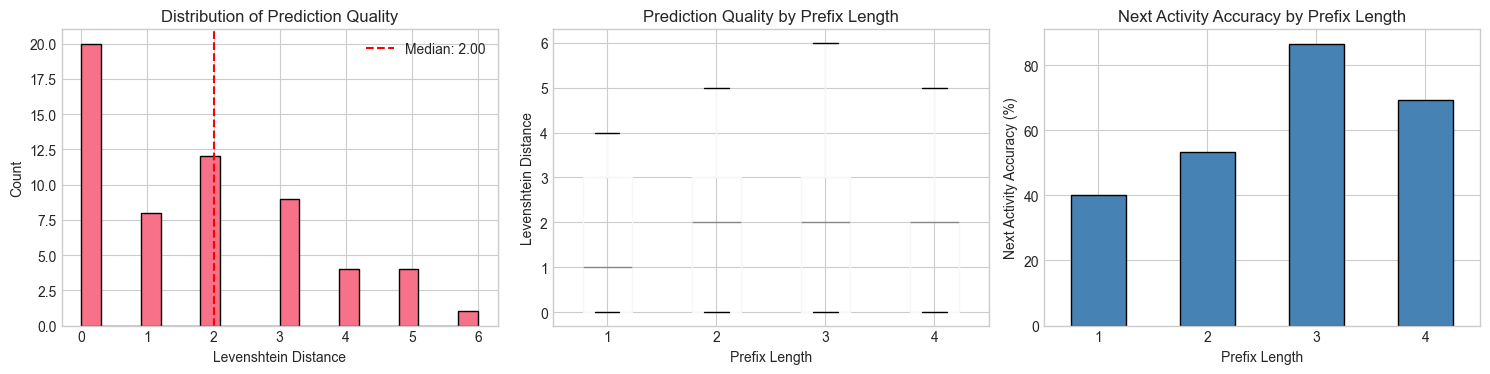

Overall next activity accuracy: 62.1%


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of Levenshtein distance
ax1 = axes[0]
results_df['avg_lev_dist_actual'].hist(bins=20, ax=ax1, edgecolor='black')
ax1.set_xlabel('Levenshtein Distance')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Prediction Quality')
ax1.axvline(results_df['avg_lev_dist_actual'].median(), color='red', linestyle='--', label=f'Median: {results_df["avg_lev_dist_actual"].median():.2f}')
ax1.legend()

# Levenshtein by prefix length
ax2 = axes[1]
results_df.boxplot(column='avg_lev_dist_actual', by='prefix_len', ax=ax2)
ax2.set_xlabel('Prefix Length')
ax2.set_ylabel('Levenshtein Distance')
ax2.set_title('Prediction Quality by Prefix Length')
plt.suptitle('')

# Next activity accuracy by prefix length
ax3 = axes[2]
acc_by_prefix = results_df.groupby('prefix_len')['next_activity_correct'].mean() * 100
acc_by_prefix.plot(kind='bar', ax=ax3, color='steelblue', edgecolor='black')
ax3.set_xlabel('Prefix Length')
ax3.set_ylabel('Next Activity Accuracy (%)')
ax3.set_title('Next Activity Accuracy by Prefix Length')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print(f"Overall next activity accuracy: {results_df['next_activity_correct'].mean()*100:.1f}%")

### 5.2 Encoder vs Decoder Attribution Split

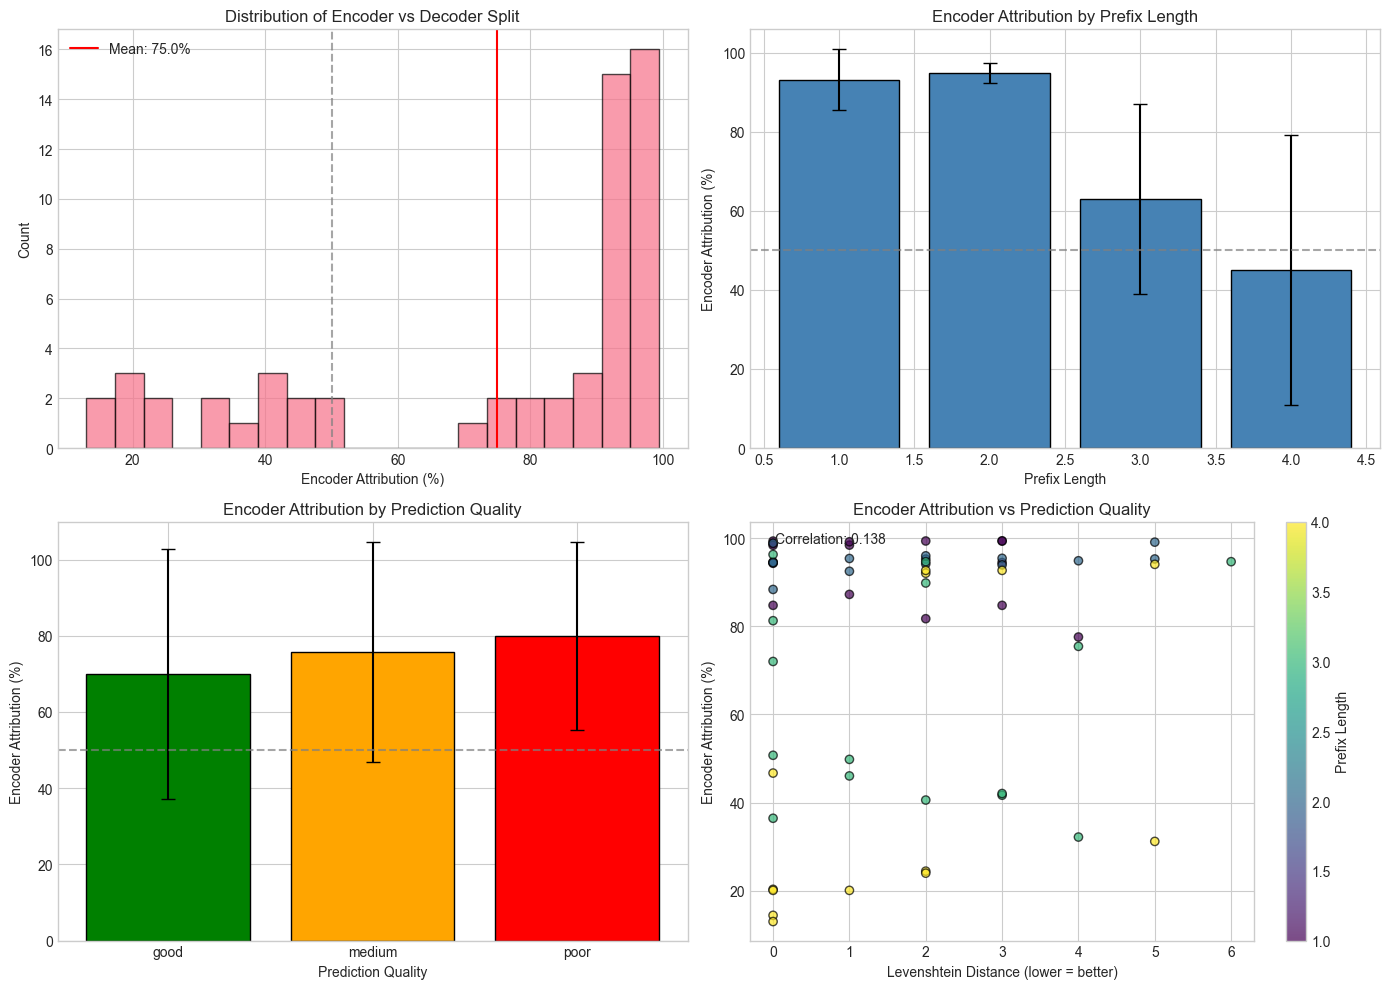

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall distribution
ax1 = axes[0, 0]
ax1.hist(results_df['encoder_fraction'] * 100, bins=20, edgecolor='black', alpha=0.7)
ax1.axvline(50, color='gray', linestyle='--', alpha=0.7)
ax1.axvline(results_df['encoder_fraction'].mean() * 100, color='red', linestyle='-', 
            label=f'Mean: {results_df["encoder_fraction"].mean()*100:.1f}%')
ax1.set_xlabel('Encoder Attribution (%)')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Encoder vs Decoder Split')
ax1.legend()

# By prefix length
ax2 = axes[0, 1]
enc_by_prefix = results_df.groupby('prefix_len')['encoder_fraction'].agg(['mean', 'std'])
x = enc_by_prefix.index
ax2.bar(x, enc_by_prefix['mean'] * 100, yerr=enc_by_prefix['std'] * 100, 
        capsize=5, color='steelblue', edgecolor='black')
ax2.axhline(50, color='gray', linestyle='--', alpha=0.7)
ax2.set_xlabel('Prefix Length')
ax2.set_ylabel('Encoder Attribution (%)')
ax2.set_title('Encoder Attribution by Prefix Length')

# By prediction quality
ax3 = axes[1, 0]
quality_order = ['good', 'medium', 'poor']
enc_by_quality = results_df.groupby('quality')['encoder_fraction'].agg(['mean', 'std']).reindex(quality_order)
colors = ['green', 'orange', 'red']
ax3.bar(range(len(quality_order)), enc_by_quality['mean'] * 100, 
        yerr=enc_by_quality['std'] * 100, capsize=5, color=colors, edgecolor='black')
ax3.set_xticks(range(len(quality_order)))
ax3.set_xticklabels(quality_order)
ax3.axhline(50, color='gray', linestyle='--', alpha=0.7)
ax3.set_xlabel('Prediction Quality')
ax3.set_ylabel('Encoder Attribution (%)')
ax3.set_title('Encoder Attribution by Prediction Quality')

# Scatter: encoder fraction vs Levenshtein
ax4 = axes[1, 1]
scatter = ax4.scatter(results_df['avg_lev_dist_actual'], results_df['encoder_fraction'] * 100,
                      c=results_df['prefix_len'], cmap='viridis', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Levenshtein Distance (lower = better)')
ax4.set_ylabel('Encoder Attribution (%)')
ax4.set_title('Encoder Attribution vs Prediction Quality')
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Prefix Length')

# Add correlation
corr = results_df['avg_lev_dist_actual'].corr(results_df['encoder_fraction'])
ax4.annotate(f'Correlation: {corr:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.show()

### 5.3 Feature Importance Analysis

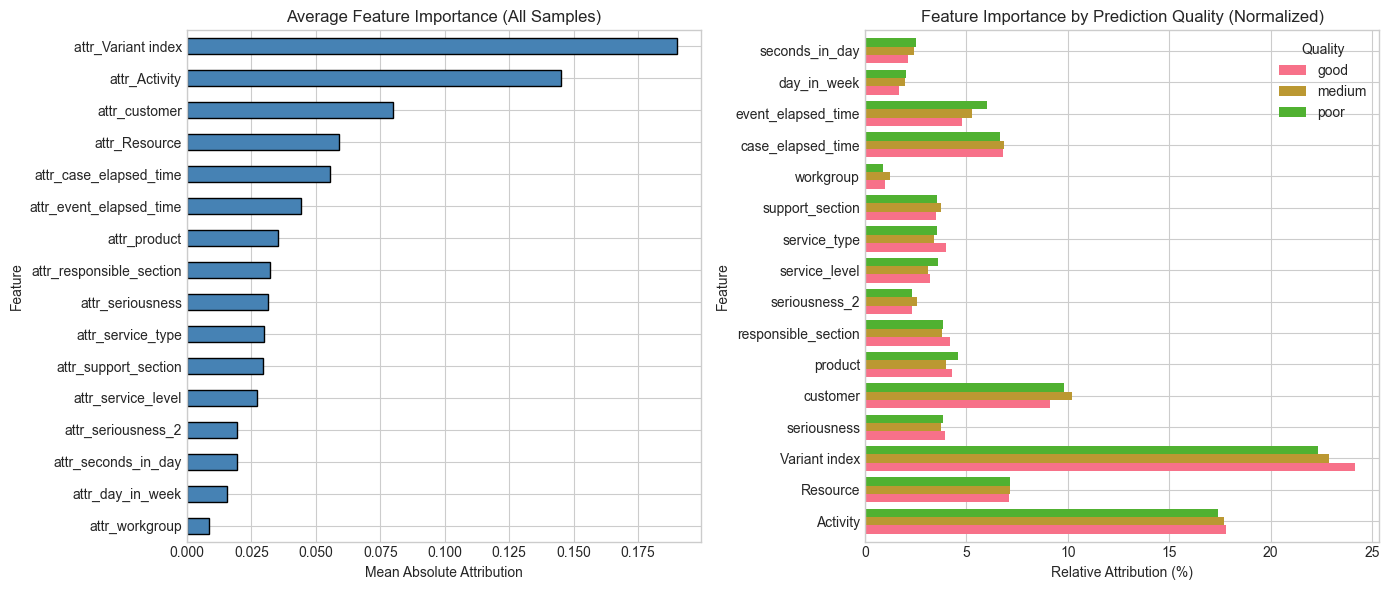

In [10]:
# Get feature columns
attr_cols = [c for c in results_df.columns if c.startswith('attr_')]
feature_names = [c.replace('attr_', '') for c in attr_cols]

# Average attribution by feature
avg_attr = results_df[attr_cols].mean().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Overall feature importance
ax1 = axes[0]
avg_attr.plot(kind='barh', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_xlabel('Mean Absolute Attribution')
ax1.set_ylabel('Feature')
ax1.set_title('Average Feature Importance (All Samples)')

# Feature importance by prediction quality
ax2 = axes[1]
quality_order = ['good', 'medium', 'poor']
feature_by_quality = results_df.groupby('quality')[attr_cols].mean().T
feature_by_quality = feature_by_quality[quality_order]
feature_by_quality.index = [c.replace('attr_', '') for c in feature_by_quality.index]

# Normalize for comparison
feature_by_quality_norm = feature_by_quality.div(feature_by_quality.sum(axis=0), axis=1) * 100

feature_by_quality_norm.plot(kind='barh', ax=ax2, width=0.8)
ax2.set_xlabel('Relative Attribution (%)')
ax2.set_ylabel('Feature')
ax2.set_title('Feature Importance by Prediction Quality (Normalized)')
ax2.legend(title='Quality')

plt.tight_layout()
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (16,) and arg 1 with shape (4,).

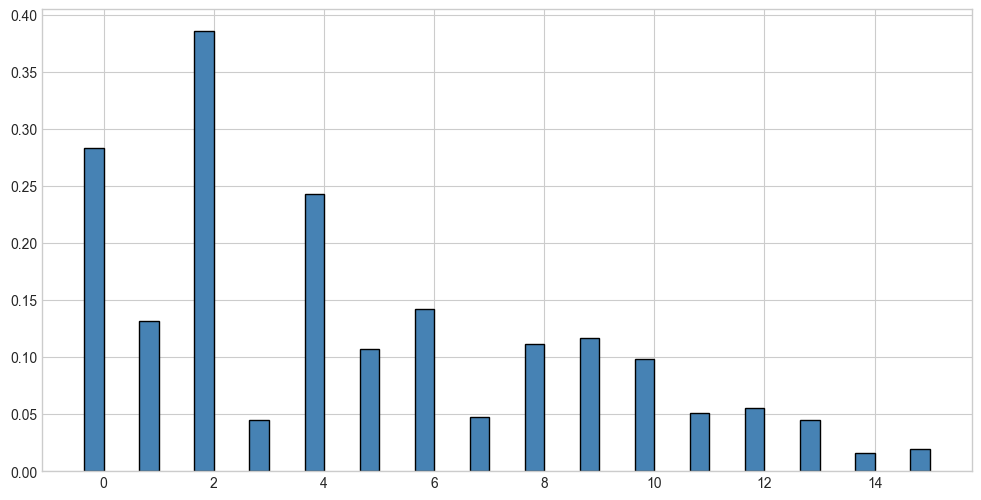

In [11]:
# Encoder vs Decoder attribution by feature
enc_cols = [c for c in results_df.columns if c.startswith('enc_')]
dec_cols = [c for c in results_df.columns if c.startswith('dec_')]

if enc_cols and dec_cols:
    enc_means = results_df[enc_cols].mean()
    dec_means = results_df[dec_cols].mean()
    
    feature_names = [c.replace('enc_', '') for c in enc_cols]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(feature_names))
    width = 0.35
    
    ax.bar(x - width/2, enc_means.values, width, label='Encoder', color='steelblue', edgecolor='black')
    ax.bar(x + width/2, dec_means.values, width, label='Decoder SOS', color='coral', edgecolor='black')
    
    ax.set_xlabel('Feature')
    ax.set_ylabel('Mean Attribution')
    ax.set_title('Encoder vs Decoder Attribution by Feature')
    ax.set_xticks(x)
    ax.set_xticklabels(feature_names, rotation=45, ha='right')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

### 5.4 Temporal Attribution Patterns

This section analyzes how attributions are distributed across different positions in the prefix sequence:
- **Recency bias**: Do recent events receive more attribution than older ones?
- **Temporal decay**: How does attribution decrease with distance from prediction time?
- **Position-specific patterns**: Are certain positions consistently more important?
- **Temporal patterns by quality**: Do good/bad predictions show different temporal patterns?

In [ ]:
# First, collect detailed temporal attribution data for each sample
# We need to re-compute attributions with position-level detail

temporal_results = []

print("Collecting detailed temporal attribution patterns...")
for idx, row in tqdm(sampled_df.iterrows(), total=len(sampled_df), desc="Extracting temporal patterns"):
    process_idx = int(row["database_index"])
    prefix_len = int(row["prefix_len"])
    
    try:
        # Load sample
        sample = test_dataset[process_idx]
        process = (sample[0], sample[1])
        
        # Compute attribution map
        attr_map = tool.compute_attribution_map(
            process=process,
            prefix_length=prefix_len,
            target="Activity",
            target_class="auto",
            suffix_scope="next",
            method="integrated_gradients",
            n_steps=50
        )
        
        # Get attribution tensor [features x timesteps]
        attr_tensor = attr_map.to_numpy()
        n_features, n_steps = attr_tensor.shape
        
        # Compute position-wise total attribution (sum over features)
        position_totals = np.abs(attr_tensor).sum(axis=0)  # [n_steps]
        total_attr = position_totals.sum()
        
        # Normalize to get fraction per position
        if total_attr > 0:
            position_fractions = position_totals / total_attr
        else:
            position_fractions = np.zeros(n_steps)
        
        # Store position-wise data (using negative indexing: -1 is last, -2 is second-to-last, etc.)
        for pos in range(n_steps):
            relative_pos = pos - n_steps  # -n_steps, ..., -1
            temporal_results.append({
                'database_index': process_idx,
                'prefix_len': prefix_len,
                'quality': row['quality'],
                'avg_lev_dist_actual': row['avg_lev_dist_actual'],
                'next_activity_correct': row['next_activity_correctness'],
                'absolute_position': pos,  # 0 = first event
                'relative_position': relative_pos,  # -1 = last event
                'position_attribution': position_totals[pos],
                'position_fraction': position_fractions[pos],
                'total_attribution': total_attr
            })
            
    except Exception as e:
        continue

temporal_df = pd.DataFrame(temporal_results)
print(f"\nCollected {len(temporal_df)} position-level attribution records")

NameError: name 'tqdm' is not defined

#### 5.4.1 Recency Bias Analysis

How much attribution goes to the most recent events vs older events?

In [ ]:
# Analyze recency bias: Attribution fraction by relative position
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Average attribution by relative position (most recent = -1)
ax1 = axes[0, 0]
# Only consider positions that exist in longer prefixes for fair comparison
rel_pos_stats = temporal_df.groupby('relative_position')['position_fraction'].agg(['mean', 'std', 'count'])
rel_pos_stats = rel_pos_stats[rel_pos_stats['count'] >= 5]  # Filter low counts

ax1.bar(rel_pos_stats.index, rel_pos_stats['mean'] * 100, 
        yerr=rel_pos_stats['std'] * 100, capsize=3, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Relative Position (−1 = most recent)')
ax1.set_ylabel('Attribution Fraction (%)')
ax1.set_title('Average Attribution by Relative Position\n(Recency Bias Analysis)')
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# Annotate with recency ratio
last_pos_attr = rel_pos_stats.loc[-1, 'mean'] if -1 in rel_pos_stats.index else 0
second_last_attr = rel_pos_stats.loc[-2, 'mean'] if -2 in rel_pos_stats.index else 0
ax1.annotate(f'Last position: {last_pos_attr*100:.1f}%', xy=(0.95, 0.95), 
             xycoords='axes fraction', ha='right', fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Cumulative attribution from most recent events
ax2 = axes[0, 1]
# For each sample, compute cumulative attribution starting from most recent
cumulative_data = []
for (db_idx, prefix_len), group in temporal_df.groupby(['database_index', 'prefix_len']):
    sorted_group = group.sort_values('relative_position', ascending=False)
    cum_attr = sorted_group['position_fraction'].cumsum()
    for i, (_, row) in enumerate(sorted_group.iterrows()):
        cumulative_data.append({
            'events_from_end': i + 1,
            'cumulative_fraction': cum_attr.iloc[i],
            'prefix_len': prefix_len,
            'quality': row['quality']
        })

cumulative_df = pd.DataFrame(cumulative_data)
cum_by_events = cumulative_df.groupby('events_from_end')['cumulative_fraction'].agg(['mean', 'std'])
cum_by_events = cum_by_events[cum_by_events.index <= 10]  # Limit to 10 events

ax2.plot(cum_by_events.index, cum_by_events['mean'] * 100, 'o-', color='steelblue', linewidth=2, markersize=8)
ax2.fill_between(cum_by_events.index, 
                 (cum_by_events['mean'] - cum_by_events['std']) * 100,
                 (cum_by_events['mean'] + cum_by_events['std']) * 100,
                 alpha=0.3, color='steelblue')
ax2.axhline(50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax2.axhline(80, color='orange', linestyle='--', alpha=0.7, label='80% threshold')
ax2.set_xlabel('Number of Most Recent Events')
ax2.set_ylabel('Cumulative Attribution (%)')
ax2.set_title('Cumulative Attribution from Most Recent Events')
ax2.legend()
ax2.set_xlim(0.5, min(10.5, cum_by_events.index.max() + 0.5))
ax2.set_ylim(0, 105)

# Find how many events capture 50% and 80% of attribution
events_for_50 = cum_by_events[cum_by_events['mean'] >= 0.5].index.min() if any(cum_by_events['mean'] >= 0.5) else 'N/A'
events_for_80 = cum_by_events[cum_by_events['mean'] >= 0.8].index.min() if any(cum_by_events['mean'] >= 0.8) else 'N/A'
ax2.annotate(f'50% at {events_for_50} events\n80% at {events_for_80} events', 
             xy=(0.95, 0.05), xycoords='axes fraction', ha='right', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Last position attribution by prefix length
ax3 = axes[1, 0]
last_pos_by_prefix = temporal_df[temporal_df['relative_position'] == -1].groupby('prefix_len')['position_fraction'].agg(['mean', 'std'])
ax3.bar(last_pos_by_prefix.index, last_pos_by_prefix['mean'] * 100,
        yerr=last_pos_by_prefix['std'] * 100, capsize=3, color='coral', edgecolor='black')
ax3.set_xlabel('Prefix Length')
ax3.set_ylabel('Last Position Attribution (%)')
ax3.set_title('Attribution to Last Event by Prefix Length')

# 4. Recency bias by prediction quality
ax4 = axes[1, 1]
quality_order = ['good', 'medium', 'poor']
colors = ['green', 'orange', 'red']

for quality, color in zip(quality_order, colors):
    subset = temporal_df[temporal_df['quality'] == quality]
    pos_stats = subset.groupby('relative_position')['position_fraction'].mean()
    pos_stats = pos_stats[pos_stats.index >= -6]  # Last 6 positions
    ax4.plot(pos_stats.index, pos_stats.values * 100, 'o-', color=color, label=quality, linewidth=2, markersize=6)

ax4.set_xlabel('Relative Position (−1 = most recent)')
ax4.set_ylabel('Attribution Fraction (%)')
ax4.set_title('Recency Bias by Prediction Quality')
ax4.legend(title='Quality')
ax4.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Print recency statistics
print("\n" + "="*60)
print("RECENCY BIAS STATISTICS")
print("="*60)
print(f"\nLast position (−1) receives {last_pos_attr*100:.1f}% of total attribution on average")
print(f"Last 2 positions receive {(last_pos_attr + second_last_attr)*100:.1f}% of total attribution")
print(f"\nEvents needed to capture 50% of attribution: {events_for_50}")
print(f"Events needed to capture 80% of attribution: {events_for_80}")

#### 5.4.2 Temporal Decay Analysis

Model the decay of attribution with distance from the prediction point.

In [ ]:
# Temporal decay analysis: Fit exponential decay model

def exponential_decay(x, a, b, c):
    """Exponential decay: a * exp(b * x) + c"""
    return a * np.exp(b * x) + c

def linear_decay(x, a, b):
    """Linear decay: a * x + b"""
    return a * x + b

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fit decay model to average attribution by position
ax1 = axes[0, 0]

# Get mean attribution by relative position (distance from end)
decay_data = temporal_df.groupby('relative_position')['position_fraction'].mean().reset_index()
decay_data = decay_data[decay_data['relative_position'] >= -10]  # Last 10 positions
decay_data['distance_from_end'] = -decay_data['relative_position']

x = decay_data['distance_from_end'].values
y = decay_data['position_fraction'].values

# Fit exponential decay
try:
    popt_exp, _ = curve_fit(exponential_decay, x, y, p0=[0.5, -0.5, 0.01], maxfev=5000)
    y_fit_exp = exponential_decay(x, *popt_exp)
    exp_fit_success = True
except:
    exp_fit_success = False

# Fit linear decay
popt_lin, _ = curve_fit(linear_decay, x, y)
y_fit_lin = linear_decay(x, *popt_lin)

# Plot
ax1.scatter(x, y * 100, s=100, color='steelblue', edgecolor='black', label='Observed', zorder=3)
ax1.plot(x, y_fit_lin * 100, 'g--', linewidth=2, label=f'Linear fit (slope={popt_lin[0]*100:.2f}%/step)')
if exp_fit_success:
    ax1.plot(x, y_fit_exp * 100, 'r-', linewidth=2, label=f'Exponential fit (decay={-popt_exp[1]:.2f})')

ax1.set_xlabel('Distance from Prediction (steps)')
ax1.set_ylabel('Attribution Fraction (%)')
ax1.set_title('Temporal Decay of Attribution')
ax1.legend()
ax1.set_xlim(-0.5, x.max() + 0.5)

# 2. Decay rate by prefix length
ax2 = axes[0, 1]
decay_rates = []

for prefix_len in sorted(temporal_df['prefix_len'].unique()):
    if prefix_len < 2:
        continue
    subset = temporal_df[temporal_df['prefix_len'] == prefix_len]
    pos_means = subset.groupby('relative_position')['position_fraction'].mean()
    
    if len(pos_means) >= 2:
        # Compute decay rate as ratio of last to second-last position
        last_attr = pos_means.get(-1, 0)
        second_last_attr = pos_means.get(-2, 0)
        if second_last_attr > 0:
            decay_ratio = last_attr / second_last_attr
        else:
            decay_ratio = np.nan
        
        # Also compute linear slope over positions
        x_pos = np.array(list(pos_means.index))
        y_pos = pos_means.values
        if len(x_pos) >= 2:
            slope, _ = np.polyfit(x_pos, y_pos, 1)
        else:
            slope = np.nan
            
        decay_rates.append({
            'prefix_len': prefix_len,
            'decay_ratio': decay_ratio,
            'slope': slope
        })

decay_rates_df = pd.DataFrame(decay_rates)

ax2.bar(decay_rates_df['prefix_len'], decay_rates_df['slope'] * 100, 
        color='purple', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Prefix Length')
ax2.set_ylabel('Attribution Slope (%/position)')
ax2.set_title('Temporal Decay Rate by Prefix Length\n(positive = more recent events more important)')
ax2.axhline(0, color='gray', linestyle='-', linewidth=0.5)

# 3. Heatmap: Attribution by relative position and prefix length
ax3 = axes[1, 0]

# Create pivot table
pivot_data = temporal_df.pivot_table(
    values='position_fraction',
    index='prefix_len',
    columns='relative_position',
    aggfunc='mean'
)
# Only keep common positions
pivot_data = pivot_data.loc[:, pivot_data.columns >= -10]

sns.heatmap(pivot_data * 100, cmap='YlOrRd', annot=True, fmt='.1f', 
            ax=ax3, cbar_kws={'label': 'Attribution %'})
ax3.set_xlabel('Relative Position (−1 = most recent)')
ax3.set_ylabel('Prefix Length')
ax3.set_title('Attribution Heatmap: Position × Prefix Length')

# 4. Half-life analysis: How many positions contain 50% of attribution?
ax4 = axes[1, 1]
half_life_data = []

for (db_idx, prefix_len), group in temporal_df.groupby(['database_index', 'prefix_len']):
    sorted_group = group.sort_values('relative_position', ascending=False)
    cum_attr = sorted_group['position_fraction'].cumsum()
    
    # Find position where cumulative > 50%
    half_life_idx = (cum_attr >= 0.5).idxmax() if any(cum_attr >= 0.5) else len(cum_attr) - 1
    half_life_pos = (cum_attr.index.get_loc(half_life_idx) + 1) if half_life_idx in cum_attr.index else prefix_len
    
    half_life_data.append({
        'prefix_len': prefix_len,
        'half_life': half_life_pos,
        'quality': sorted_group['quality'].iloc[0]
    })

half_life_df = pd.DataFrame(half_life_data)
half_life_by_prefix = half_life_df.groupby('prefix_len')['half_life'].agg(['mean', 'std'])

ax4.bar(half_life_by_prefix.index, half_life_by_prefix['mean'],
        yerr=half_life_by_prefix['std'], capsize=3, color='teal', edgecolor='black')
ax4.plot(half_life_by_prefix.index, half_life_by_prefix.index, 'r--', label='y=x (uniform distribution)')
ax4.set_xlabel('Prefix Length')
ax4.set_ylabel('Attribution Half-Life (# of recent events)')
ax4.set_title('Attribution Half-Life by Prefix Length\n(# events from end containing 50% attribution)')
ax4.legend()

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "="*60)
print("TEMPORAL DECAY STATISTICS")
print("="*60)
print(f"\nLinear decay slope: {popt_lin[0]*100:.3f}% per position")
if exp_fit_success:
    print(f"Exponential decay rate: {-popt_exp[1]:.3f}")
print(f"\nAverage attribution half-life: {half_life_df['half_life'].mean():.1f} events")
print(f"  (This means on average, the last {half_life_df['half_life'].mean():.1f} events contain 50% of total attribution)")

#### 5.4.3 Temporal Patterns and Prediction Quality

Do good predictions show different temporal attribution patterns than poor predictions?

In [ ]:
# Analyze temporal patterns by prediction quality
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

quality_order = ['good', 'medium', 'poor']
colors = {'good': 'green', 'medium': 'orange', 'poor': 'red'}

# 1. Attribution distribution by position for each quality level
ax1 = axes[0, 0]
for quality in quality_order:
    subset = temporal_df[temporal_df['quality'] == quality]
    pos_means = subset.groupby('relative_position')['position_fraction'].mean()
    pos_means = pos_means[pos_means.index >= -8]
    ax1.plot(pos_means.index, pos_means.values * 100, 'o-', 
             color=colors[quality], label=quality, linewidth=2, markersize=6)

ax1.set_xlabel('Relative Position (−1 = most recent)')
ax1.set_ylabel('Attribution Fraction (%)')
ax1.set_title('Temporal Attribution Profile by Quality')
ax1.legend(title='Prediction Quality')
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# 2. First position importance by quality
ax2 = axes[0, 1]
first_pos_by_quality = temporal_df[temporal_df['absolute_position'] == 0].groupby('quality')['position_fraction'].agg(['mean', 'std'])
first_pos_by_quality = first_pos_by_quality.reindex(quality_order)

bar_colors = [colors[q] for q in quality_order]
ax2.bar(range(len(quality_order)), first_pos_by_quality['mean'] * 100,
        yerr=first_pos_by_quality['std'] * 100, capsize=5, color=bar_colors, edgecolor='black')
ax2.set_xticks(range(len(quality_order)))
ax2.set_xticklabels(quality_order)
ax2.set_xlabel('Prediction Quality')
ax2.set_ylabel('First Position Attribution (%)')
ax2.set_title('Attribution to First Event by Quality\n(Beginning of Trace Importance)')

# 3. Last position importance by quality  
ax3 = axes[0, 2]
last_pos_by_quality = temporal_df[temporal_df['relative_position'] == -1].groupby('quality')['position_fraction'].agg(['mean', 'std'])
last_pos_by_quality = last_pos_by_quality.reindex(quality_order)

ax3.bar(range(len(quality_order)), last_pos_by_quality['mean'] * 100,
        yerr=last_pos_by_quality['std'] * 100, capsize=5, color=bar_colors, edgecolor='black')
ax3.set_xticks(range(len(quality_order)))
ax3.set_xticklabels(quality_order)
ax3.set_xlabel('Prediction Quality')
ax3.set_ylabel('Last Position Attribution (%)')
ax3.set_title('Attribution to Last Event by Quality\n(Most Recent Event Importance)')

# 4. Attribution concentration (Gini coefficient) by quality
ax4 = axes[1, 0]

def gini_coefficient(x):
    """Compute Gini coefficient for concentration measurement."""
    x = np.array(x)
    x = x[x > 0]  # Remove zeros
    if len(x) == 0:
        return 0
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * x) / (n * np.sum(x))) - (n + 1) / n

gini_data = []
for (db_idx, prefix_len), group in temporal_df.groupby(['database_index', 'prefix_len']):
    fractions = group['position_fraction'].values
    gini = gini_coefficient(fractions)
    gini_data.append({
        'prefix_len': prefix_len,
        'quality': group['quality'].iloc[0],
        'gini': gini
    })

gini_df = pd.DataFrame(gini_data)
gini_by_quality = gini_df.groupby('quality')['gini'].agg(['mean', 'std']).reindex(quality_order)

ax4.bar(range(len(quality_order)), gini_by_quality['mean'],
        yerr=gini_by_quality['std'], capsize=5, color=bar_colors, edgecolor='black')
ax4.set_xticks(range(len(quality_order)))
ax4.set_xticklabels(quality_order)
ax4.set_xlabel('Prediction Quality')
ax4.set_ylabel('Gini Coefficient')
ax4.set_title('Attribution Concentration by Quality\n(Higher = more concentrated on few positions)')

# 5. Attribution entropy by quality
ax5 = axes[1, 1]

def normalized_entropy(x):
    """Compute normalized entropy for distribution uniformity."""
    x = np.array(x)
    x = x[x > 0]  # Remove zeros
    if len(x) <= 1:
        return 0
    x = x / x.sum()  # Normalize
    entropy = -np.sum(x * np.log(x + 1e-10))
    max_entropy = np.log(len(x))
    return entropy / max_entropy if max_entropy > 0 else 0

entropy_data = []
for (db_idx, prefix_len), group in temporal_df.groupby(['database_index', 'prefix_len']):
    fractions = group['position_fraction'].values
    ent = normalized_entropy(fractions)
    entropy_data.append({
        'prefix_len': prefix_len,
        'quality': group['quality'].iloc[0],
        'entropy': ent
    })

entropy_df = pd.DataFrame(entropy_data)
entropy_by_quality = entropy_df.groupby('quality')['entropy'].agg(['mean', 'std']).reindex(quality_order)

ax5.bar(range(len(quality_order)), entropy_by_quality['mean'],
        yerr=entropy_by_quality['std'], capsize=5, color=bar_colors, edgecolor='black')
ax5.set_xticks(range(len(quality_order)))
ax5.set_xticklabels(quality_order)
ax5.set_xlabel('Prediction Quality')
ax5.set_ylabel('Normalized Entropy')
ax5.set_title('Attribution Entropy by Quality\n(Higher = more uniform distribution)')

# 6. Scatter: Attribution concentration vs Levenshtein
ax6 = axes[1, 2]
merged_gini = gini_df.merge(
    temporal_df[['database_index', 'prefix_len', 'avg_lev_dist_actual']].drop_duplicates(),
    on=['database_index', 'prefix_len']
)

scatter = ax6.scatter(merged_gini['avg_lev_dist_actual'], merged_gini['gini'],
                      c=[colors[q] for q in merged_gini['quality']], 
                      alpha=0.6, edgecolor='black', s=80)
ax6.set_xlabel('Levenshtein Distance (lower = better)')
ax6.set_ylabel('Gini Coefficient (attribution concentration)')
ax6.set_title('Attribution Concentration vs Prediction Quality')

# Add correlation
corr, pval = pearsonr(merged_gini['avg_lev_dist_actual'], merged_gini['gini'])
ax6.annotate(f'r = {corr:.3f}\np = {pval:.4f}', xy=(0.05, 0.95), 
             xycoords='axes fraction', fontsize=10, va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[q], edgecolor='black', label=q) for q in quality_order]
ax6.legend(handles=legend_elements, title='Quality')

plt.tight_layout()
plt.show()

# Statistical tests
print("\n" + "="*70)
print("TEMPORAL PATTERNS AND PREDICTION QUALITY - STATISTICAL ANALYSIS")
print("="*70)

# T-tests between good and poor predictions
from scipy.stats import ttest_ind, mannwhitneyu

good_last = temporal_df[(temporal_df['quality'] == 'good') & (temporal_df['relative_position'] == -1)]['position_fraction']
poor_last = temporal_df[(temporal_df['quality'] == 'poor') & (temporal_df['relative_position'] == -1)]['position_fraction']

if len(good_last) > 0 and len(poor_last) > 0:
    t_stat, p_val = ttest_ind(good_last, poor_last)
    u_stat, u_pval = mannwhitneyu(good_last, poor_last, alternative='two-sided')
    
    print(f"\nLast Position Attribution (Good vs Poor):")
    print(f"  Good predictions: {good_last.mean()*100:.1f}% ± {good_last.std()*100:.1f}%")
    print(f"  Poor predictions: {poor_last.mean()*100:.1f}% ± {poor_last.std()*100:.1f}%")
    print(f"  T-test: t={t_stat:.3f}, p={p_val:.4f}")
    print(f"  Mann-Whitney U: U={u_stat:.0f}, p={u_pval:.4f}")

good_gini = gini_df[gini_df['quality'] == 'good']['gini']
poor_gini = gini_df[gini_df['quality'] == 'poor']['gini']

if len(good_gini) > 0 and len(poor_gini) > 0:
    t_stat, p_val = ttest_ind(good_gini, poor_gini)
    
    print(f"\nAttribution Concentration (Good vs Poor):")
    print(f"  Good predictions (Gini): {good_gini.mean():.3f} ± {good_gini.std():.3f}")
    print(f"  Poor predictions (Gini): {poor_gini.mean():.3f} ± {poor_gini.std():.3f}")
    print(f"  T-test: t={t_stat:.3f}, p={p_val:.4f}")

print(f"\nCorrelation: Attribution concentration vs Levenshtein: r={corr:.3f} (p={pval:.4f})")

### 5.5 Correlation Analysis

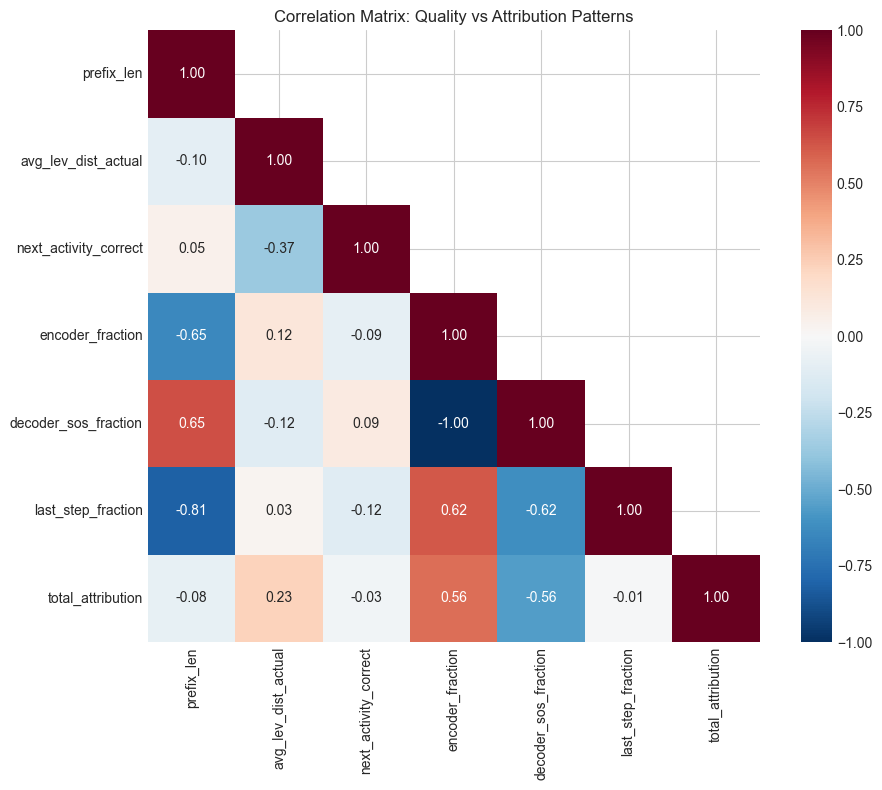

In [ ]:
# Select relevant columns for correlation
corr_cols = [
    'prefix_len', 'avg_lev_dist_actual', 'next_activity_correct',
    'encoder_fraction', 'decoder_sos_fraction', 'last_step_fraction', 'total_attribution'
]
corr_cols = [c for c in corr_cols if c in results_df.columns]

# Compute correlation matrix
corr_matrix = results_df[corr_cols].corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix: Quality vs Attribution Patterns')
plt.tight_layout()
plt.show()

## 6. Summary Statistics

In [ ]:
print("=" * 70)
print("ATTRIBUTION ANALYSIS SUMMARY")
print("=" * 70)
print(f"\nTotal samples analyzed: {len(results_df)}")
print(f"Prefix lengths: {sorted(results_df['prefix_len'].unique())}")

print("\n" + "-" * 70)
print("PREDICTION QUALITY")
print("-" * 70)
print(f"Mean Levenshtein distance: {results_df['avg_lev_dist_actual'].mean():.2f} ± {results_df['avg_lev_dist_actual'].std():.2f}")
print(f"Next activity accuracy: {results_df['next_activity_correct'].mean()*100:.1f}%")

print("\n" + "-" * 70)
print("ENCODER vs DECODER SPLIT")
print("-" * 70)
print(f"Mean encoder fraction: {results_df['encoder_fraction'].mean()*100:.1f}% ± {results_df['encoder_fraction'].std()*100:.1f}%")
print(f"Mean decoder SOS fraction: {results_df['decoder_sos_fraction'].mean()*100:.1f}% ± {results_df['decoder_sos_fraction'].std()*100:.1f}%")

print("\nBy prediction quality:")
for quality in ['good', 'medium', 'poor']:
    subset = results_df[results_df['quality'] == quality]
    if len(subset) > 0:
        print(f"  {quality:8s}: Encoder {subset['encoder_fraction'].mean()*100:.1f}% | Decoder {subset['decoder_sos_fraction'].mean()*100:.1f}%")

print("\n" + "-" * 70)
print("TOP FEATURES BY ATTRIBUTION")
print("-" * 70)
top_features = results_df[attr_cols].mean().sort_values(ascending=False).head(5)
for feat, val in top_features.items():
    print(f"  {feat.replace('attr_', ''):25s}: {val:.4f}")

print("\n" + "-" * 70)
print("KEY CORRELATIONS WITH PREDICTION QUALITY")
print("-" * 70)
lev_corrs = results_df[corr_cols].corrwith(results_df['avg_lev_dist_actual']).drop('avg_lev_dist_actual').sort_values()
for col, corr in lev_corrs.items():
    print(f"  {col:25s}: r = {corr:+.3f}")

print("\n" + "=" * 70)

ATTRIBUTION ANALYSIS SUMMARY

Total samples analyzed: 123
Prefix lengths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

----------------------------------------------------------------------
PREDICTION QUALITY
----------------------------------------------------------------------
Mean Levenshtein distance: 1.74 ± 1.75
Next activity accuracy: 60.2%

----------------------------------------------------------------------
ENCODER vs DECODER SPLIT
----------------------------------------------------------------------
Mean encoder fraction: 61.8% ± 26.5%
Mean decoder SOS fraction: 38.2% ± 26.5%

By prediction quality:
  good    : Encoder 58.6% | Decoder 41.4%
  medium  : Encoder 61.9% | Decoder 38.1%
  poor    : Encoder 65.6% | Decoder 34.4%

----------------------------------------------------------------------
TOP FEATURES BY ATTRIBUTION
----------------------------------------------------------------------
  Variant index            : 0.1608
  Activity                 : 0.1405
  customer          

## 7. Key Insights

Based on the analysis above, document your key findings:

In [ ]:
# Compute some automatic insights
insights = []

# Encoder dominance
enc_mean = results_df['encoder_fraction'].mean()
if enc_mean > 0.7:
    insights.append(f"The encoder (historical context) dominates attribution ({enc_mean*100:.0f}%), suggesting the model relies heavily on the full prefix history.")
elif enc_mean < 0.3:
    insights.append(f"The decoder SOS (last event) dominates attribution ({(1-enc_mean)*100:.0f}%), suggesting the model primarily uses the most recent event.")
else:
    insights.append(f"Attribution is relatively balanced between encoder ({enc_mean*100:.0f}%) and decoder ({(1-enc_mean)*100:.0f}%).")

# Quality correlation
quality_corr = results_df['avg_lev_dist_actual'].corr(results_df['encoder_fraction'])
if abs(quality_corr) > 0.2:
    direction = "higher" if quality_corr > 0 else "lower"
    insights.append(f"There's a correlation (r={quality_corr:.2f}) between encoder fraction and prediction quality: {direction} encoder attribution is associated with {'worse' if quality_corr > 0 else 'better'} predictions.")

# Prefix length effect
prefix_corr = results_df['prefix_len'].corr(results_df['encoder_fraction'])
if abs(prefix_corr) > 0.2:
    direction = "increases" if prefix_corr > 0 else "decreases"
    insights.append(f"Encoder attribution {direction} with prefix length (r={prefix_corr:.2f}).")

print("AUTOMATICALLY DETECTED INSIGHTS:")
print("=" * 50)
for i, insight in enumerate(insights, 1):
    print(f"\n{i}. {insight}")

AUTOMATICALLY DETECTED INSIGHTS:

1. Attribution is relatively balanced between encoder (62%) and decoder (38%).

2. Encoder attribution decreases with prefix length (r=-0.65).
